In [23]:
!rm -rf sample_data/

In [24]:
import requests
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [25]:
file_name = './TSLA.csv'

In [26]:
def download_tsla_csv():
  """Downloads TSLA.csv if it doesn't already exist."""
  if not os.path.exists('TSLA.csv'):
    url = 'https://raw.githubusercontent.com/JeremyTubongbanua/sofe4620u-tsla-stock-prediction/trunk/TSLA.csv'
    response = requests.get(url)
    if response.status_code == 200:
      with open('TSLA.csv', 'wb') as f:
        f.write(response.content)
      print('TSLA.csv downloaded successfully.')
    else:
      print('Failed to download TSLA.csv.')
  else:
    print('TSLA.csv already exists.')

download_tsla_csv()

TSLA.csv already exists.


In [27]:
df = pd.read_csv(file_name)
print(f'df length: {len(df)}')
print(f'{df.head()}')

df length: 2956
         Date   Open   High    Low  Close  Adj Close    Volume
0  2010-06-29  3.800  5.000  3.508  4.778      4.778  93831500
1  2010-06-30  5.158  6.084  4.660  4.766      4.766  85935500
2  2010-07-01  5.000  5.184  4.054  4.392      4.392  41094000
3  2010-07-02  4.600  4.620  3.742  3.840      3.840  25699000
4  2010-07-06  4.000  4.000  3.166  3.222      3.222  34334500


In [28]:
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda
Could not fetch market data for ^GSPC. Proceeding without market data.
Processed dataframe shape: (2747, 74)
Top positively correlated features:
Target_1d      1.000000
Target_3d      0.370850
Target_5d      0.254975
Target_10d     0.179978
MACD_Signal    0.031256
Name: Target_1d, dtype: float64

Top negatively correlated features:
Target_Return_10d   -0.210118
Target_Return_5d    -0.292566
Target_Return_3d    -0.385331
Target_Return_1d    -0.683177
Name: Target_1d, dtype: float64

Selected 10 features: ['MACD_Signal', 'Target_Return_10d', 'Target_Return_5d', 'Target_Return_3d', 'Target_Return_1d', 'Open', 'High', 'Low', 'Close', 'Volume']
Selected 10 features
Class balance: 1412/2727 positive samples (51.78%)
Training set: (2181, 20, 10), Test set: (546, 20, 10)
Class weight for positive samples: 1.9578
Using class weights: {0: 1.0, 1: np.float64(1.9578096947935368)}
Using prediction threshold: 0.4

Training the model...


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/80, Train Loss: 0.9390, Train Acc: 53.83%, Val Loss: 1.1518, Val Acc: 57.51%, Precision: 0.6250, Recall: 0.5537, F1: 0.5872, AUC: 0.6694
Epoch 2/80, Train Loss: 0.6633, Train Acc: 70.88%, Val Loss: 1.1951, Val Acc: 62.82%, Precision: 0.5979, Recall: 0.9732, F1: 0.7407, AUC: 0.7730
Epoch 3/80, Train Loss: 0.6091, Train Acc: 76.34%, Val Loss: 0.8922, Val Acc: 67.77%, Precision: 0.6432, Recall: 0.9195, F1: 0.7569, AUC: 0.7986
Epoch 4/80, Train Loss: 0.6021, Train Acc: 76.11%, Val Loss: 3.3618, Val Acc: 59.34%, Precision: 0.8958, Recall: 0.2886, F1: 0.4365, AUC: 0.7168
Epoch 5/80, Train Loss: 0.5709, Train Acc: 79.05%, Val Loss: 6.7116, Val Acc: 57.69%, Precision: 0.9351, Recall: 0.2416, F1: 0.3840, AUC: 0.6154
Epoch 6/80, Train Loss: 0.5245, Train Acc: 81.20%, Val Loss: 1.7538, Val Acc: 62.09%, Precision: 0.6188, Recall: 0.7953, F1: 0.6960, AUC: 0.6848
Epoch 7/80, Train Loss: 0.4945, Train Acc: 81.16%, Val Loss: 2.3383, Val Acc: 59.89%, Precision: 0.6985, Recall: 0.4664, F1: 0.559

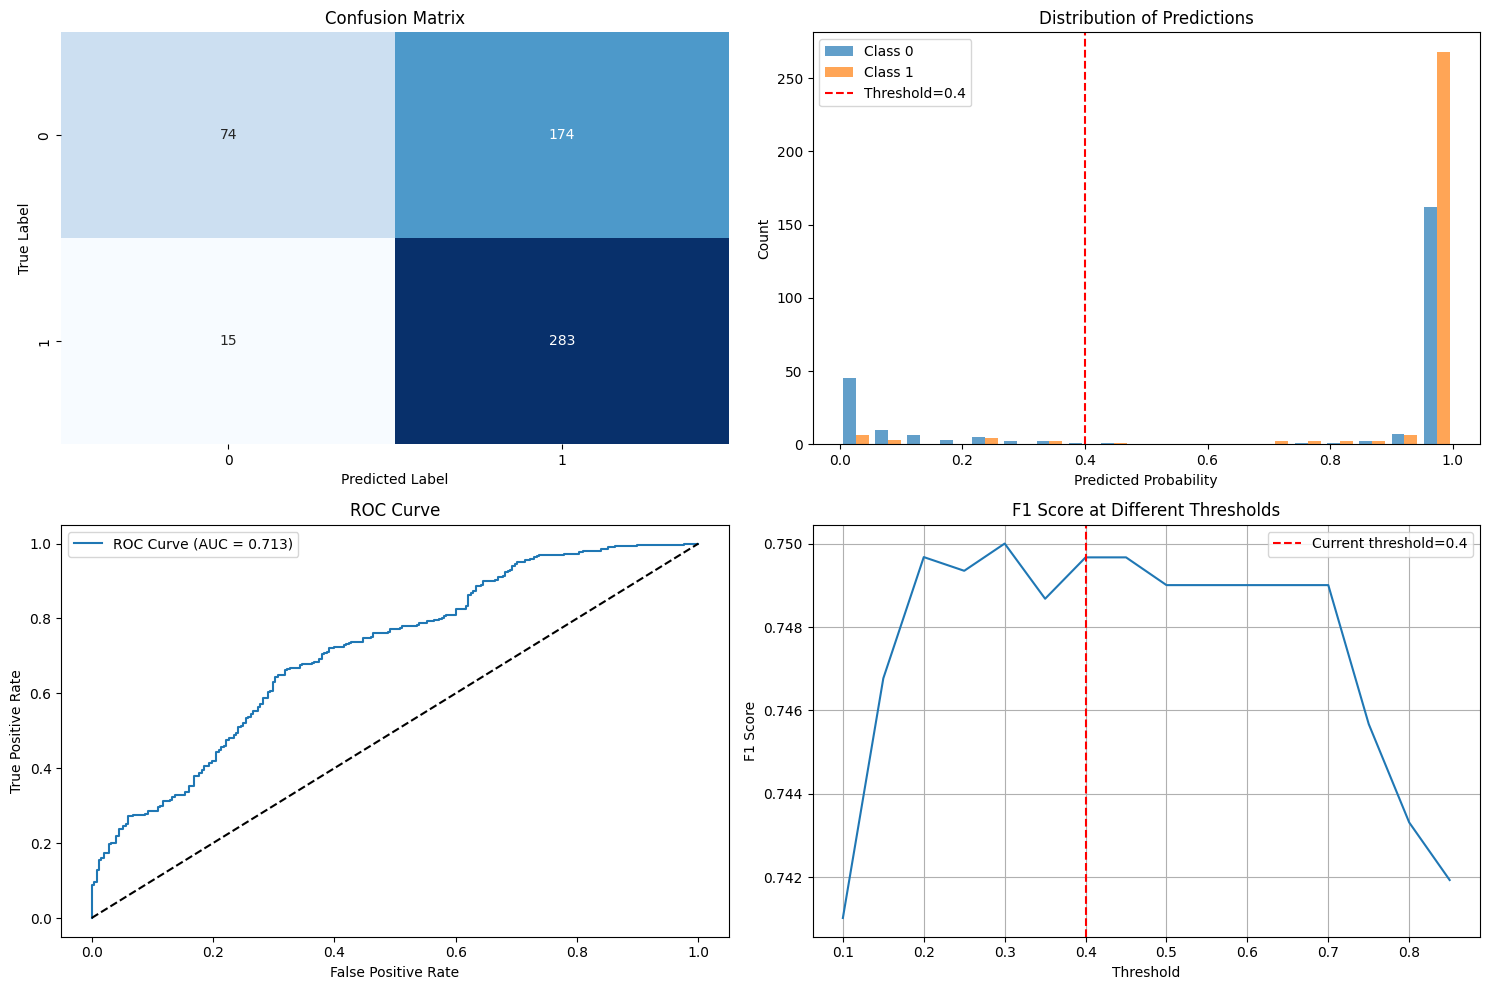

Model and components saved to tesla_model_improved/

Creating trading strategy...

Simulating trade at price $809.87
Signal: BUY, Confidence: 0.9953, Market: neutral
Buy 0.03 shares ($25.15)

Model training and evaluation complete.


In [31]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import joblib
import pandas_datareader as pdr
from datetime import datetime, timedelta

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def preprocess_data(df, market_df=None):
    df = df.copy()

    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

    for window in [5, 10, 20, 50, 100, 200]:
        if len(df) >= window:
            df[f'MA{window}'] = df['Close'].rolling(window=window).mean()

    if 'MA50' in df.columns:
        df['Price_to_MA50'] = df['Close'] / df['MA50']

    if 'MA200' in df.columns:
        df['Price_to_MA200'] = df['Close'] / df['MA200']
        df['Golden_Cross'] = (df['MA50'] > df['MA200']).astype(int)
        df['Death_Cross'] = (df['MA50'] < df['MA200']).astype(int)

    for period in [1, 3, 5, 10, 21]:
        df[f'Return_{period}d'] = df['Close'].pct_change(periods=period) * 100

    if 'Return_1d' in df.columns:
        for window in [5, 10, 20, 50]:
            if len(df) >= window:
                df[f'Volatility_{window}d'] = df['Return_1d'].rolling(window=window).std()

    df['High_Low'] = df['High'] - df['Low']
    df['High_PrevClose'] = abs(df['High'] - df['Close'].shift(1))
    df['Low_PrevClose'] = abs(df['Low'] - df['Close'].shift(1))
    df['TR'] = df[['High_Low', 'High_PrevClose', 'Low_PrevClose']].max(axis=1)
    df['ATR_14'] = df['TR'].rolling(window=14).mean()
    df['ATR_Ratio'] = df['ATR_14'] / df['Close'] * 100

    if 'Open' in df.columns and 'Close' in df.columns:
        df['Daily_Range'] = (df['High'] - df['Low']) / df['Open'] * 100
        df['Daily_Range_MA5'] = df['Daily_Range'].rolling(window=5).mean()
        df['Daily_Range_MA20'] = df['Daily_Range'].rolling(window=20).mean()
        df['Gap_Up'] = ((df['Open'] > df['Close'].shift(1)) & (df['Open'] > df['Open'].shift(1))).astype(int)
        df['Gap_Down'] = ((df['Open'] < df['Close'].shift(1)) & (df['Open'] < df['Open'].shift(1))).astype(int)

    def calculate_rsi(data, period=14):
        delta = data.diff()
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)

        avg_gain = gain.ewm(com=period-1, adjust=False).mean()
        avg_loss = loss.ewm(com=period-1, adjust=False).mean()

        avg_loss = avg_loss.replace(0, 0.001)

        rs = avg_gain / avg_loss
        rsi = 100 - (100 / (1 + rs))
        return rsi

    for period in [7, 9, 14, 21]:
        df[f'RSI_{period}'] = calculate_rsi(df['Close'], period=period)

    df['RSI_Oversold'] = (df['RSI_14'] < 30).astype(int)
    df['RSI_Overbought'] = (df['RSI_14'] > 70).astype(int)

    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
    df['MACD_Crossover'] = ((df['MACD'] > df['MACD_Signal']) & (df['MACD'].shift(1) <= df['MACD_Signal'].shift(1))).astype(int)
    df['MACD_Crossunder'] = ((df['MACD'] < df['MACD_Signal']) & (df['MACD'].shift(1) >= df['MACD_Signal'].shift(1))).astype(int)

    df['BB_Middle'] = df['Close'].rolling(window=20).mean()
    df['BB_Std'] = df['Close'].rolling(window=20).std()
    df['BB_Upper'] = df['BB_Middle'] + (df['BB_Std'] * 2)
    df['BB_Lower'] = df['BB_Middle'] - (df['BB_Std'] * 2)
    df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / df['BB_Middle']
    df['BB_Pct'] = (df['Close'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'])

    low_14 = df['Low'].rolling(window=14).min()
    high_14 = df['High'].rolling(window=14).max()
    df['Stoch_K'] = 100 * ((df['Close'] - low_14) / (high_14 - low_14 + 1e-12))
    df['Stoch_D'] = df['Stoch_K'].rolling(window=3).mean()
    df['Stoch_Crossover'] = ((df['Stoch_K'] > df['Stoch_D']) & (df['Stoch_K'].shift(1) <= df['Stoch_D'].shift(1))).astype(int)
    df['Stoch_Crossunder'] = ((df['Stoch_K'] < df['Stoch_D']) & (df['Stoch_K'].shift(1) >= df['Stoch_D'].shift(1))).astype(int)

    df['Volume_Change'] = df['Volume'].pct_change() * 100
    df['Volume_MA5'] = df['Volume'].rolling(window=5).mean()
    df['Volume_MA20'] = df['Volume'].rolling(window=20).mean()
    df['Volume_Ratio'] = df['Volume'] / df['Volume_MA20']
    df['High_Volume'] = (df['Volume'] > 1.5 * df['Volume_MA20']).astype(int)

    df['OBV'] = np.where(df['Close'] > df['Close'].shift(1),
                         df['Volume'],
                         np.where(df['Close'] < df['Close'].shift(1),
                                 -df['Volume'], 0)).cumsum()
    df['OBV_MA20'] = df['OBV'].rolling(window=20).mean()
    df['OBV_Divergence'] = np.where((df['Close'] > df['Close'].shift(5)) & (df['OBV'] < df['OBV'].shift(5)), -1,
                                    np.where((df['Close'] < df['Close'].shift(5)) & (df['OBV'] > df['OBV'].shift(5)), 1, 0))

    if market_df is not None:
        market_df['Date'] = pd.to_datetime(market_df['Date'])
        market_df = market_df.rename(columns={
            'Close': 'Market_Close',
            'Volume': 'Market_Volume'
        })
        market_df['Market_Return'] = market_df['Market_Close'].pct_change() * 100

        for window in [10, 20, 60]:
            if len(market_df) >= window:
                market_df[f'Market_MA{window}'] = market_df['Market_Close'].rolling(window=window).mean()
                market_df[f'Market_Return_{window}d'] = market_df['Market_Close'].pct_change(periods=window) * 100

        market_cols_to_keep = ['Date', 'Market_Close', 'Market_Return', 'Market_MA20', 'Market_Volume',
                               'Market_Return_10d', 'Market_Return_20d']
        market_df = market_df[market_cols_to_keep].dropna()

        df = pd.merge(df, market_df, on='Date', how='left')

        for window in [20, 60]:
            if len(df) >= window and 'Market_Return' in df.columns:
                df[f'Market_Correlation_{window}d'] = df['Return_1d'].rolling(window=window).corr(df['Market_Return'])

        df['Relative_Strength'] = df['Close'] / df['Market_Close']
        df['RS_Change'] = df['Relative_Strength'].pct_change() * 100
        df['RS_Trend'] = np.where(df['Relative_Strength'] > df['Relative_Strength'].rolling(window=20).mean(), 1, -1)

    for horizon in [1, 3, 5, 10]:
        df[f'Target_{horizon}d'] = (df['Close'].shift(-horizon) > df['Close']).astype(int)
        df[f'Target_Return_{horizon}d'] = df['Close'].pct_change(periods=-horizon) * 100

    df = df.dropna().reset_index(drop=True)

    return df

def fetch_market_data(start_date, end_date, symbol='^GSPC'):
    try:
        market_data = pdr.data.DataReader(symbol, 'yahoo', start_date, end_date)
        market_data = market_data.reset_index()
        return market_data
    except:
        print(f"Could not fetch market data for {symbol}. Proceeding without market data.")
        return None

def select_important_features(df, target_col='Target_1d', correlation_threshold=0.03):
    corr_with_target = df.corr()[target_col].sort_values(ascending=False)

    print("Top positively correlated features:")
    print(corr_with_target[corr_with_target > correlation_threshold].head(15))

    print("\nTop negatively correlated features:")
    print(corr_with_target[corr_with_target < -correlation_threshold].head(15))

    important_features = list(corr_with_target[abs(corr_with_target) > correlation_threshold].index)
    if target_col in important_features:
        important_features.remove(target_col)

    for field in ['Target_3d', 'Target_5d', 'Target_10d']:
        if field in important_features:
            important_features.remove(field)

    base_features = ['Open', 'High', 'Low', 'Close', 'Volume']
    for feat in base_features:
        if feat not in important_features and feat in df.columns:
            important_features.append(feat)

    print(f"\nSelected {len(important_features)} features: {important_features}")
    return important_features

def prepare_lstm_data(df, features, target_col='Target_1d', seq_length=20, test_size=0.2):
    X = df[features].values
    y = df[target_col].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_seq, y_seq = [], []
    for i in range(len(X_scaled) - seq_length):
        X_seq.append(X_scaled[i:i+seq_length])
        y_seq.append(y[i+seq_length])

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)

    positives = np.sum(y_seq)
    total = len(y_seq)
    print(f"Class balance: {positives}/{total} positive samples ({positives/total:.2%})")

    split_idx = int(len(X_seq) * (1 - test_size))
    X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
    y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

    print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

    return X_train, X_test, y_train, y_test, scaler, features

class StockDataset(Dataset):
    def __init__(self, X, y, augment=False, class_weights=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.augment = augment
        self.class_weights = class_weights

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]

        if self.augment and np.random.random() < 0.2:
            noise_level = 0.02
            x = x + torch.randn_like(x) * noise_level

            if np.random.random() < 0.1:
                sequence_length = x.shape[0]
                mask_idx = np.random.randint(0, sequence_length-5)
                mask_length = np.random.randint(1, 4)

                for i in range(mask_idx, min(mask_idx + mask_length, sequence_length)):
                    if i < sequence_length:
                        x[i] = x[i-1] if i > 0 else x[i]

        weight = 1.0
        if self.class_weights is not None:
            weight = self.class_weights[int(y.item())]

        return x, y, weight

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        BCE_loss = self.bce(inputs, targets)
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss

        if self.reduction == 'mean':
            return torch.mean(F_loss)
        elif self.reduction == 'sum':
            return torch.sum(F_loss)
        else:
            return F_loss

class WeightedBCELoss(nn.Module):
    def __init__(self, pos_weight=2.0):
        super(WeightedBCELoss, self).__init__()
        self.pos_weight = pos_weight

    def forward(self, outputs, targets, weights=None):
        loss = nn.BCELoss(reduction='none')(outputs, targets)

        if weights is None:
            weights = torch.ones_like(targets)
            weights[targets == 1] = self.pos_weight

        weighted_loss = loss * weights
        return weighted_loss.mean()

class LSTMWithAttention(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, bidirectional=True, dropout=0.3):
        super(LSTMWithAttention, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_size * self.directions, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.fc1 = nn.Linear(hidden_size * self.directions, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(dropout * 0.5)

        self.fc3 = nn.Linear(64, output_size)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        batch_size = x.size(0)
        seq_length = x.size(1)

        h0 = torch.zeros(self.num_layers * self.directions, batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers * self.directions, batch_size, self.hidden_size).to(x.device)

        output, _ = self.lstm(x, (h0, c0))

        attention_weights = self.attention(output).squeeze(-1)
        attention_weights = torch.softmax(attention_weights, dim=1)

        context_vector = torch.bmm(
            attention_weights.unsqueeze(1),
            output
        ).squeeze(1)

        out = self.fc1(context_vector)
        out = self.bn1(out)
        out = torch.relu(out)
        out = self.dropout1(out)

        out = self.fc2(out)
        out = self.bn2(out)
        out = torch.relu(out)
        out = self.dropout2(out)

        out = self.fc3(out)
        out = self.sigmoid(out)

        return out

def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, epochs=50, patience=10, device=device,
                threshold=0.4):
    model = model.to(device)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_loss = float('inf')
    best_val_f1 = 0
    best_model_state = None

    counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        for X_batch, y_batch, weights in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            weights = weights.to(device)

            y_batch = y_batch.unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(X_batch)

            if isinstance(criterion, WeightedBCELoss):
                loss = criterion(outputs, y_batch, weights.unsqueeze(1))
            else:
                loss = criterion(outputs, y_batch)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            train_loss += loss.item()
            predicted = (outputs >= threshold).float()
            train_total += y_batch.size(0)
            train_correct += (predicted == y_batch).sum().item()

        train_loss /= len(train_loader)
        train_acc = 100 * train_correct / train_total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        y_true, y_pred, y_scores = [], [], []

        with torch.no_grad():
            for X_batch, y_batch, weights in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                weights = weights.to(device)

                y_batch = y_batch.unsqueeze(1)
                outputs = model(X_batch)

                if isinstance(criterion, WeightedBCELoss):
                    loss = criterion(outputs, y_batch, weights.unsqueeze(1))
                else:
                    loss = criterion(outputs, y_batch)

                val_loss += loss.item()
                predicted = (outputs >= threshold).float()
                val_total += y_batch.size(0)
                val_correct += (predicted == y_batch).sum().item()

                y_true.extend(y_batch.cpu().numpy())
                y_pred.extend(predicted.cpu().numpy())
                y_scores.extend(outputs.cpu().numpy())

        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        y_true = np.array(y_true).reshape(-1)
        y_pred = np.array(y_pred).reshape(-1)
        y_scores = np.array(y_scores).reshape(-1)

        val_precision = precision_score(y_true, y_pred, zero_division=0)
        val_recall = recall_score(y_true, y_pred, zero_division=0)
        val_f1 = f1_score(y_true, y_pred, zero_division=0)
        val_auc = roc_auc_score(y_true, y_scores) if len(np.unique(y_true)) > 1 else 0.5

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, "
              f"Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}, AUC: {val_auc:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = model.state_dict()
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if y_true.size > 0 and y_pred.size > 0:
        print("\nValidation Metrics:")
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        auc = roc_auc_score(y_true, y_scores) if len(np.unique(y_true)) > 1 else 0.5
        print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}, AUC: {auc:.4f}")

        cm = confusion_matrix(y_true, y_pred)
        print("Confusion Matrix:")
        print(cm)

    if best_model_state:
        model.load_state_dict(best_model_state)

    return model, train_losses, val_losses, train_accs, val_accs, threshold

def evaluate_model(model, test_loader, threshold=0.4, device=device):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch, _ in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            probs = outputs.cpu().numpy().flatten()
            predicted = (outputs >= threshold).float().cpu().numpy().flatten()

            all_probs.extend(probs)
            all_preds.extend(predicted)
            all_labels.extend(y_batch.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.5

    cm = confusion_matrix(all_labels, all_preds)

    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test Precision: {prec:.4f}")
    print(f"Test Recall: {rec:.4f}")
    print(f"Test F1 Score: {f1:.4f}")
    print(f"Test AUC: {auc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")

    plt.subplot(2, 2, 2)
    bins = np.linspace(0, 1, 20)
    plt.hist(
        [
            np.array(all_probs)[np.array(all_labels) == 0],
            np.array(all_probs)[np.array(all_labels) == 1]
        ],
        bins,
        label=['Class 0', 'Class 1'],
        alpha=0.7,
        stacked=False
    )
    plt.axvline(x=threshold, color='red', linestyle='--', label=f'Threshold={threshold}')
    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.title("Distribution of Predictions")
    plt.legend()

    plt.subplot(2, 2, 3)
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()

    plt.subplot(2, 2, 4)
    thresholds_to_test = np.arange(0.1, 0.9, 0.05)
    f1_scores = []

    for thresh in thresholds_to_test:
        test_preds = (np.array(all_probs) >= thresh).astype(int)
        f1 = f1_score(all_labels, test_preds, zero_division=0)
        f1_scores.append(f1)

    plt.plot(thresholds_to_test, f1_scores)
    plt.axvline(x=threshold, color='red', linestyle='--', label=f'Current threshold={threshold}')
    plt.xlabel('Threshold')
    plt.ylabel('F1 Score')
    plt.title('F1 Score at Different Thresholds')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig('model_evaluation.png')
    plt.show()

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'auc': auc,
        'confusion_matrix': cm,
        'probabilities': all_probs,
        'predictions': all_preds,
        'true_labels': all_labels
    }

class AdvancedTradingStrategy:
    def __init__(self, model, scaler, features, seq_length, risk_per_trade=0.02, prediction_threshold=0.4):
        self.model = model
        self.scaler = scaler
        self.features = features
        self.seq_length = seq_length
        self.risk_per_trade = risk_per_trade
        self.prediction_threshold = prediction_threshold
        self.previous_signals = []
        self.max_signals_stored = 10

    def predict(self, data):
        data = data[self.features].values

        data_scaled = self.scaler.transform(data)

        X_seq = np.array([data_scaled[-self.seq_length:]])
        X_tensor = torch.tensor(X_seq, dtype=torch.float32).to(next(self.model.parameters()).device)

        self.model.eval()
        with torch.no_grad():
            prediction = self.model(X_tensor)

        confidence = prediction.item()

        return confidence

    def calculate_position_size(self, capital, confidence, current_price, volatility=None, stop_loss_pct=0.02):
        confidence_factor = (confidence - self.prediction_threshold) / (1 - self.prediction_threshold)
        confidence_factor = max(0, min(1, confidence_factor * 1.5))

        if volatility is not None:
            risk_adjusted = self.risk_per_trade / (volatility / 10)
            risk_amount = capital * min(0.05, max(0.01, risk_adjusted))
        else:
            risk_amount = capital * self.risk_per_trade

        stop_loss_distance = current_price * stop_loss_pct

        base_position = risk_amount / stop_loss_distance if stop_loss_distance > 0 else 0

        adjusted_position = base_position * confidence_factor * confidence_factor

        max_position = capital * 0.95
        position_size = min(adjusted_position, max_position)

        shares = max(0, position_size / current_price)

        return shares

    def analyze_market_condition(self, data):
        condition = "neutral"
        volatility = None
        stop_loss_pct = 0.02

        if 'Volatility_20d' in data.columns:
            volatility = data['Volatility_20d'].iloc[-1]
            avg_volatility = data['Volatility_20d'].iloc[-20:].mean()

            if volatility > avg_volatility * 1.5:
                condition = "high_volatility"
                stop_loss_pct = 0.03
            elif volatility < avg_volatility * 0.7:
                condition = "low_volatility"
                stop_loss_pct = 0.015

        if 'BB_Width' in data.columns:
            bb_width = data['BB_Width'].iloc[-1]
            avg_bb_width = data['BB_Width'].iloc[-20:].mean()

            if bb_width > avg_bb_width * 1.3:
                condition = "expanding_range"
            elif bb_width < avg_bb_width * 0.7:
                condition = "contracting_range"

        if 'RSI_14' in data.columns:
            rsi = data['RSI_14'].iloc[-1]
            if rsi > 70:
                condition = "overbought"
            elif rsi < 30:
                condition = "oversold"

        return condition, volatility, stop_loss_pct

    def generate_signal(self, data, capital, shares_owned, current_price):
        confidence = self.predict(data)

        self.previous_signals.append(confidence)
        if len(self.previous_signals) > self.max_signals_stored:
            self.previous_signals.pop(0)

        market_condition, volatility, stop_loss_pct = self.analyze_market_condition(data)

        buy_threshold = self.prediction_threshold + 0.15
        sell_threshold = self.prediction_threshold - 0.05

        signal_trend = 0
        if len(self.previous_signals) >= 3:
            recent_signals = self.previous_signals[-3:]
            if all(b > a for a, b in zip(recent_signals, recent_signals[1:])):
                signal_trend = 1
                buy_threshold -= 0.05
            elif all(b < a for a, b in zip(recent_signals, recent_signals[1:])):
                signal_trend = -1
                sell_threshold += 0.05

        if market_condition == "high_volatility":
            buy_threshold += 0.05
            sell_threshold -= 0.05
        elif market_condition == "overbought":
            buy_threshold += 0.1
        elif market_condition == "oversold":
            sell_threshold += 0.05

        if confidence >= buy_threshold and capital > 0:
            action = "BUY"

            shares_to_buy = self.calculate_position_size(
                capital, confidence, current_price, volatility, stop_loss_pct
            )

            return action, shares_to_buy, confidence, market_condition

        elif confidence <= sell_threshold and shares_owned > 0:
            action = "SELL"

            sell_strength = (sell_threshold - confidence) / sell_threshold
            sell_ratio = min(1.0, max(0.5, 0.5 + sell_strength))

            if market_condition in ["high_volatility", "overbought"]:
                sell_ratio = min(1.0, sell_ratio + 0.2)

            shares_to_sell = shares_owned * sell_ratio

            return action, shares_to_sell, confidence, market_condition

        else:
            return "HOLD", 0, confidence, market_condition

def save_model(model, optimizer, scaler, features, seq_length, threshold=0.4, model_dir='tesla_model_improved'):
    if not os.path.exists(model_dir):
        os.makedirs(model_dir)

    torch.save(model.state_dict(), os.path.join(model_dir, 'model.pt'))
    torch.save(optimizer.state_dict(), os.path.join(model_dir, 'optimizer.pt'))

    joblib.dump(scaler, os.path.join(model_dir, 'scaler.joblib'))

    metadata = {
        'features': features,
        'seq_length': seq_length,
        'input_size': len(features),
        'hidden_size': model.hidden_size,
        'num_layers': model.num_layers,
        'output_size': 1,
        'bidirectional': model.bidirectional,
        'threshold': threshold
    }

    with open(os.path.join(model_dir, 'metadata.json'), 'w') as f:
        json.dump(metadata, f)

    print(f"Model and components saved to {model_dir}/")

def load_model(model_dir='tesla_model_improved'):
    with open(os.path.join(model_dir, 'metadata.json'), 'r') as f:
        metadata = json.load(f)

    model = LSTMWithAttention(
        input_size=metadata['input_size'],
        hidden_size=metadata['hidden_size'],
        num_layers=metadata['num_layers'],
        output_size=metadata['output_size'],
        bidirectional=metadata.get('bidirectional', True)
    )

    model.load_state_dict(torch.load(os.path.join(model_dir, 'model.pt')))
    model.eval()

    scaler = joblib.load(os.path.join(model_dir, 'scaler.joblib'))

    threshold = metadata.get('threshold', 0.5)

    return model, scaler, metadata, threshold

def main():
    try:
        start_date = datetime.now() - timedelta(days=2000)
        end_date = datetime.now()
        market_df = fetch_market_data(start_date, end_date)
    except:
        market_df = None
        print("Could not fetch market data, proceeding without it")

    processed_df = preprocess_data(df, market_df)
    print(f"Processed dataframe shape: {processed_df.shape}")

    features = select_important_features(processed_df, target_col='Target_1d', correlation_threshold=0.03)
    print(f"Selected {len(features)} features")

    seq_length = 20
    X_train, X_test, y_train, y_test, scaler, features = prepare_lstm_data(
        processed_df, features, target_col='Target_1d', seq_length=seq_length
    )

    pos_weight = len(y_train) / max(np.sum(y_train), 1)
    print(f"Class weight for positive samples: {pos_weight:.4f}")

    class_weights = {
        0: 1.0,
        1: min(2.5, max(1.5, pos_weight))
    }
    print(f"Using class weights: {class_weights}")

    prediction_threshold = 0.4
    print(f"Using prediction threshold: {prediction_threshold}")

    batch_size = 32
    train_dataset = StockDataset(X_train, y_train, augment=True, class_weights=class_weights)
    test_dataset = StockDataset(X_test, y_test, augment=False, class_weights=class_weights)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    input_size = X_train.shape[2]
    hidden_size = 192
    num_layers = 3
    output_size = 1

    model = LSTMWithAttention(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        output_size=output_size,
        bidirectional=True,
        dropout=0.35
    )

    criterion = WeightedBCELoss(pos_weight=2.0)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=True
    )

    print("\nTraining the model...")
    model, train_losses, val_losses, train_accs, val_accs, best_threshold = train_model(
        model, train_loader, test_loader, criterion, optimizer,
        scheduler=scheduler, epochs=80, patience=15, device=device,
        threshold=prediction_threshold
    )

    print("\nEvaluating the model on test data...")
    metrics = evaluate_model(model, test_loader, threshold=best_threshold, device=device)

    save_model(model, optimizer, scaler, features, seq_length, threshold=best_threshold)

    print("\nCreating trading strategy...")
    strategy = AdvancedTradingStrategy(
        model, scaler, features, seq_length, risk_per_trade=0.02,
        prediction_threshold=best_threshold
    )

    last_data = processed_df.iloc[-seq_length-10:-10]
    current_price = processed_df['Close'].iloc[-10]
    capital = 10000.0
    shares_owned = 0.0

    print(f"\nSimulating trade at price ${current_price:.2f}")
    action, quantity, confidence, market_condition = strategy.generate_signal(
        last_data, capital, shares_owned, current_price
    )

    print(f"Signal: {action}, Confidence: {confidence:.4f}, Market: {market_condition}")
    if action == "BUY":
        print(f"Buy {quantity:.2f} shares (${quantity * current_price:.2f})")
    elif action == "SELL":
        print(f"Sell {quantity:.2f} shares (${quantity * current_price:.2f})")
    else:
        print("Hold position")

    print("\nModel training and evaluation complete.")

main()